Epoch 1/180


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.1086 - val_loss: 0.0523
Epoch 2/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0270 - val_loss: 0.0232
Epoch 3/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0230 - val_loss: 0.0313
Epoch 4/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0189 - val_loss: 0.0273
Epoch 5/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0170 - val_loss: 0.0233
Epoch 6/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0159 - val_loss: 0.0229
Epoch 7/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0143 - val_loss: 0.0202
Epoch 8/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0144 - val_loss: 0.0174
Epoch 9/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0125 - val_loss: 0.0163
Epoch 10/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0130 - val_loss: 0.0183
Epoch 11/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0135 - val_loss: 0.0193
Epoch 12/180
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.

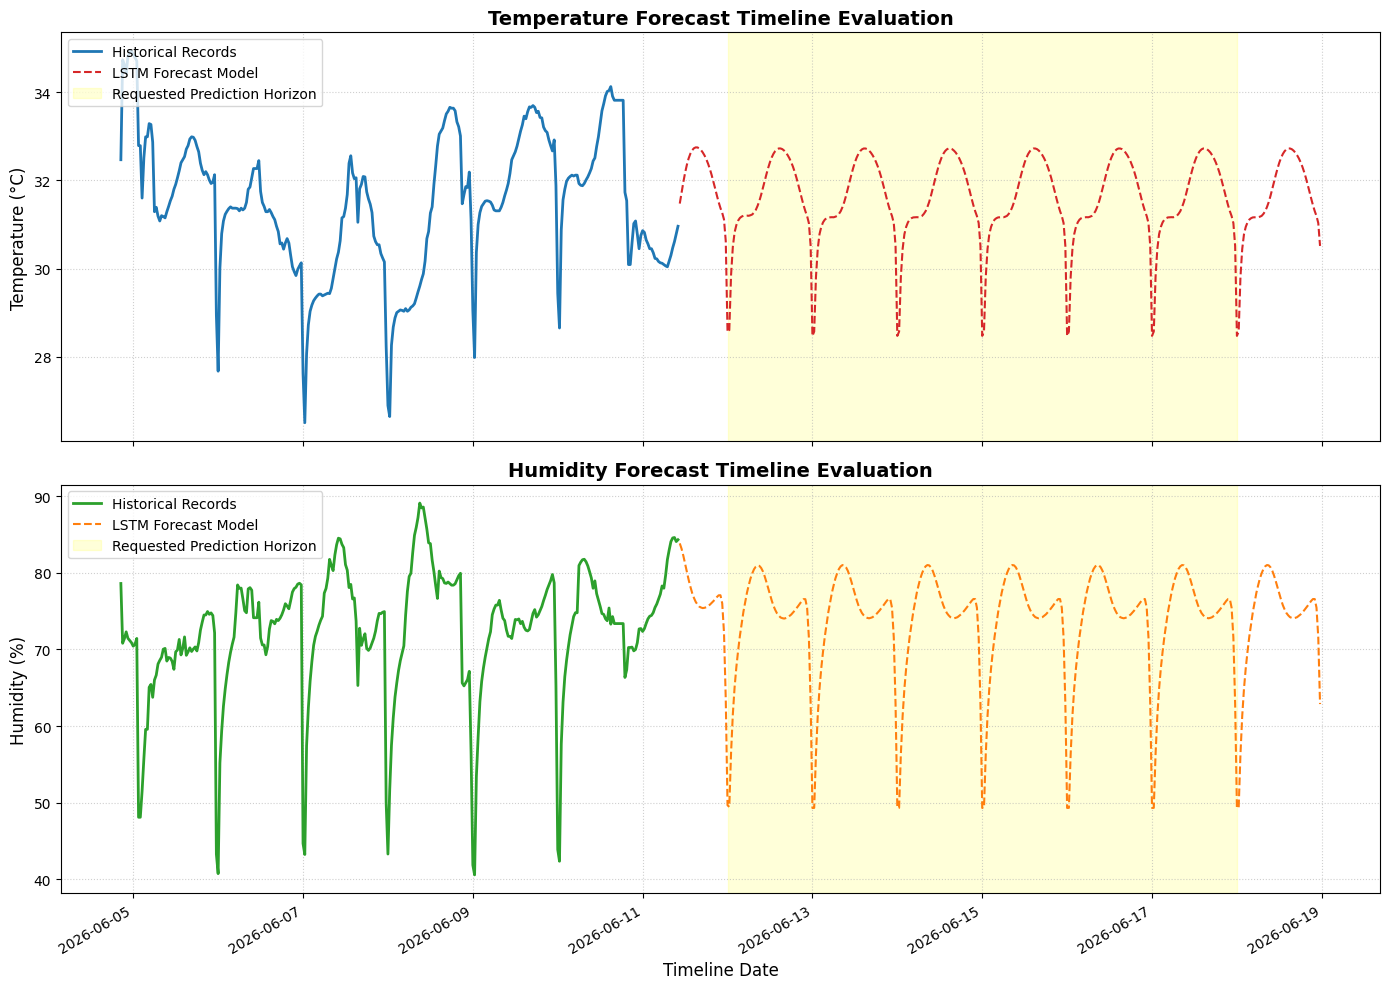

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 1. LOAD DATA & ENGINEER CYCLICAL TIME FEATURES
# ==========================================
file_path = 'Hardware_read - Sheet.csv'
df = pd.read_csv(file_path)

df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)
df = df.sort_values('Timestamp').set_index('Timestamp')

# Resample to strict 30-minute intervals and forward-fill gaps
df = df.resample('30min').mean().ffill()

# Create cyclical time anchors (Hour mapping into Sine/Cosine waves)
df['Hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24.0)
df['Hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24.0)

features = ['Temperature(C)', 'Humidity(%)']
target_data = df[features].values

# Scale target variables between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
target_scaled = scaler.fit_transform(target_data)

# Combine scaled targets with engineered time features
# Shape layout per row: [Scaled_Temp, Scaled_Hum, Hour_sin, Hour_cos]
all_features = np.hstack([target_scaled, df[['Hour_sin', 'Hour_cos']].values])

# ==========================================
# 2. CHRONOLOGICAL SPLITING (TRAIN / CV / TEST)
# ==========================================
n = len(all_features)
train_end = int(n * 0.70)   # 70% Training
val_end = int(n * 0.85)     # 15% Cross-Validation (Validation Set)
                            # 15% Test Set

train_slice = all_features[:train_end]
val_slice = all_features[train_end:val_end]
test_slice = all_features[val_end:]

# ==========================================
# 3. WINDOW TIMELINE SEQUENCE CREATION
# ==========================================
def create_sequences(dataset, look_back=24):
    """Uses past 12 hours (24 half-hour steps) to predict the next measurement step."""
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back)])
        y.append(dataset[i + look_back, :2]) # Target columns: [Temp, Hum]
    return np.array(X), np.array(y)

look_back = 24
X_train, y_train = create_sequences(train_slice, look_back)
X_val, y_val = create_sequences(val_slice, look_back)
X_test, y_test = create_sequences(test_slice, look_back)

# ==========================================
# 4. DESIGN AND TRAIN LSTM MODEL
# ==========================================
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(look_back, 4)),
    Dropout(0.1),
    LSTM(32, activation='tanh', return_sequences=False),
    Dense(2)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=180,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 5. CALCULATE ACCURACY PERFORMANCE METRIC (RMSE)
# ==========================================
# Generate predictions on the unseen Test partition
test_preds_scaled = model.predict(X_test, verbose=0)

# De-normalize predictions and actual values back to original units (°C and %)
test_preds = scaler.inverse_transform(test_preds_scaled)
test_actuals = scaler.inverse_transform(y_test)

# Calculate separate Root Mean Squared Error values
rmse_temp = np.sqrt(mean_squared_error(test_actuals[:, 0], test_preds[:, 0]))
rmse_hum = np.sqrt(mean_squared_error(test_actuals[:, 1], test_preds[:, 1]))

print("\n" + "="*50)
print(f"MODEL PERFORMANCE ACCURACY (RMSE ON HELD-OUT TEST DATA):")
print(f"  • Temperature Prediction RMSE: {rmse_temp:.4f} °C")
print(f"  • Humidity Prediction RMSE:    {rmse_hum:.4f} %")
print("="*50 + "\n")

# ==========================================
# 6. FUTURE FORECAST LOOP (JUNE 12 TO JUNE 18)
# ==========================================
start_forecast = df.index[-1] + pd.Timedelta(minutes=30)
end_forecast = pd.to_datetime('2026-06-18 23:30:00')
future_timeline = pd.date_range(start=start_forecast, end=end_forecast, freq='30min')

current_batch = all_features[-look_back:].reshape((1, look_back, 4))
future_predictions = []

for i in range(len(future_timeline)):
    pred_step = model.predict(current_batch, verbose=0)[0]
    future_predictions.append(pred_step)

    step_time = future_timeline[i]
    h_sin = np.sin(2 * np.pi * step_time.hour / 24.0)
    h_cos = np.cos(2 * np.pi * step_time.hour / 24.0)

    next_feature_row = np.array([pred_step[0], pred_step[1], h_sin, h_cos])
    current_batch = np.append(current_batch[:, 1:, :], [[next_feature_row]], axis=1)

future_predictions = scaler.inverse_transform(future_predictions)
full_forecast_df = pd.DataFrame(future_predictions, index=future_timeline, columns=features)

# Slice the target dates requested
requested_forecast_df = full_forecast_df.loc['2026-06-12':'2026-06-18']
requested_forecast_df.to_csv('7_Day_LSTM_Forecast_With_Metrics.csv')

# ==========================================
# 7. GENERATE DYNAMIC ALIGNED GRAPH VISUALIZATION
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Temperature Plot Panel
axes[0].plot(df.index, df['Temperature(C)'], label='Historical Records', color='#1f77b4', lw=2)
axes[0].plot(full_forecast_df.index, full_forecast_df['Temperature(C)'], label='LSTM Forecast Model', color='#d62728', linestyle='--')
axes[0].axvspan('2026-06-12', '2026-06-18', color='yellow', alpha=0.15, label='Requested Prediction Horizon')
axes[0].set_title('Temperature Forecast Timeline Evaluation', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)', fontsize=12)
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Humidity Plot Panel
axes[1].plot(df.index, df['Humidity(%)'], label='Historical Records', color='#2ca02c', lw=2)
axes[1].plot(full_forecast_df.index, full_forecast_df['Humidity(%)'], label='LSTM Forecast Model', color='#ff7f0e', linestyle='--')
axes[1].axvspan('2026-06-12', '2026-06-18', color='yellow', alpha=0.15, label='Requested Prediction Horizon')
axes[1].set_title('Humidity Forecast Timeline Evaluation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Timeline Date', fontsize=12)
axes[1].set_ylabel('Humidity (%)', fontsize=12)
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig('lstm_forecast_with_rmse.png', dpi=300)

print("Process finished! Predictions saved in '7_Day_LSTM_Forecast_With_Metrics.csv'.")
print("Visualized graph saved as 'lstm_forecast_with_rmse.png'.")